#**Detección y Diagnóstico de Fallos en Centros de Mecanizado**

##**1. EDA and Physics Analysis**

##**Comenzamos con la importación de las librerías y el dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

ruta = "/content/ai4i2020.csv"

df = pd.read_csv(ruta)

In [ ]:
df.shape

(10000, 14)

###Renombramos columnas, quitamos unidades

In [ ]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [ ]:
df.columns = ['UDI', 'Product_ID', 'Type', 'Air_temperature',
       'Process_temperature', 'Rotational_speed', 'Torque',
       'Tool_wear', 'Machine_failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF']

###Eliminamos variables que no necesitamos

In [ ]:
df.drop(columns=['UDI', 'Product_ID'], inplace=True)

##**Visualizaciones: El Torque y el Desgaste (Tool Wear)**

Aquí es donde aplicamos la Ingeniería Mecánica. En una herramienta de corte (fresa/broca), a medida que el filo se desgasta (Tool Wear), aumenta la fricción y la resistencia al avance, lo que suele requerir un Torque mayor para mantener la velocidad.

###**Visualización 1: El Scatter Plot de la "Zona Crítica"**

No busques una línea recta. Busca la envolvente de fallo. En este dataset, el fallo por sobreesfuerzo (OSF) ocurre cuando el producto de Torque y Tool Wear supera un umbral físico.

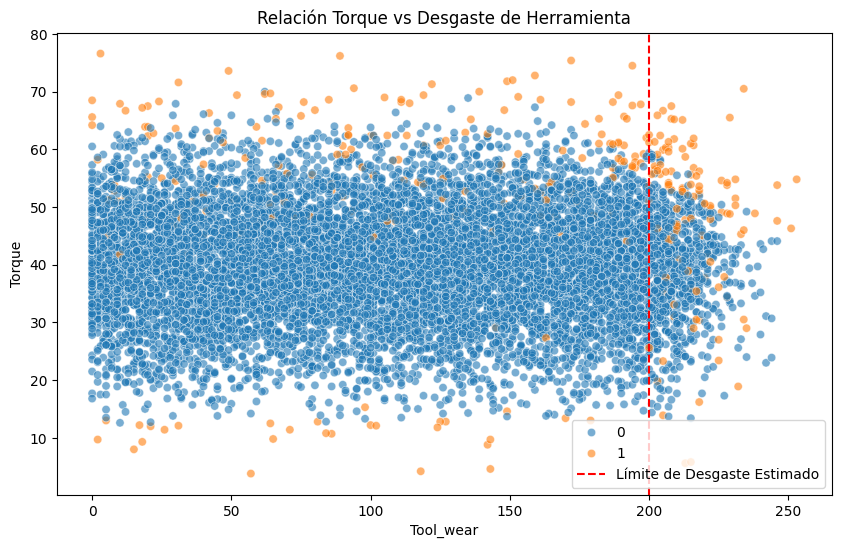

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Tool_wear', y='Torque', hue='Machine_failure', alpha=0.6)
plt.title('Relación Torque vs Desgaste de Herramienta')
plt.axvline(x=200, color='r', linestyle='--', label='Límite de Desgaste Estimado')
plt.legend()
plt.show()

###**Visualización 2: El JointPlot (Distribución + Correlación)**

Usar esta vez un sns.jointplot con kind="hex" o kind="kde". Esto te permitirá ver dónde se concentra la operación normal de la máquina y detectar si los fallos ocurren en los extremos de la campana de Gauss del Torque.

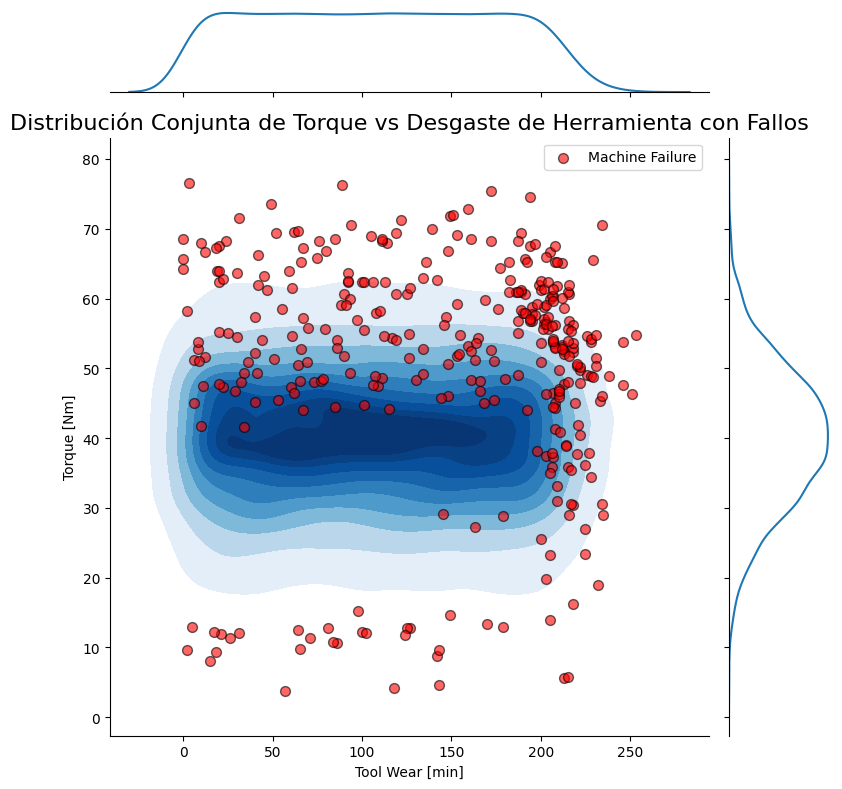

In [ ]:
g = sns.jointplot(data=df, x='Tool_wear', y='Torque', kind="kde", cmap="Blues", fill=True, height=8, marginal_kws=dict(fill=False))

# Overlay failure points on the jointplot
df_failure = df[df['Machine_failure'] == 1]
g.ax_joint.scatter(df_failure['Tool_wear'], df_failure['Torque'], color='red', s=50, alpha=0.6, label='Machine Failure', edgecolor='black')
g.ax_joint.set_xlabel('Tool Wear [min]')
g.ax_joint.set_ylabel('Torque [Nm]')
g.ax_joint.set_title('Distribución Conjunta de Torque vs Desgaste de Herramienta con Fallos', fontsize=16)
g.ax_joint.legend()
plt.tight_layout()
plt.show()

En este `jointplot` con `kind="kde"`, las áreas azules representan la concentración de operaciones normales de la máquina. Las curvas marginales muestran las distribuciones individuales de 'Tool Wear' y 'Torque'.

Los puntos rojos superpuestos indican las instancias de fallos de la máquina. Podemos observar visualmente si estos fallos se agrupan en regiones de alta densidad (operación normal) o en las colas/extremos de la distribución, lo que podría sugerir condiciones anómalas.

Lo que más me gusta de este gráfico es cómo los bordes (los histogramas marginales) te dicen la verdad de la máquina:

* **La "Mancha Azul" (Estado Estacionario):** La máquina pasa la mayor parte de su tiempo operando entre 35 y 55 Nm de Torque y de manera uniforme en el desgaste. Es una operación estable.

* **La Anomalía del Torque:** Fíjate en el eje Y del scatter. Hay fallos a Torque muy bajo (< 15 Nm) y muy alto (> 70 Nm) que se salen completamente de la zona azul de densidad.

* **Insights para el Portfolio:** "El 90% de la operación normal ocurre en el núcleo azul, pero los fallos se dispersan como 'outliers' en el espacio de fases". Esto justifica por qué un modelo lineal fallaría y por qué necesitamos algo más complejo.

###**Visualización 3: Análisis de Fallos Específicos (OSF)**

Como el dataset divide los fallos por tipo, crea un gráfico centrado en el **Overstrain Failure (OSF)**.

**Intuición Física:** Es el "límite elástico" de la herramienta. Si el torque es muy alto y la herramienta está muy desgastada, se rompe.

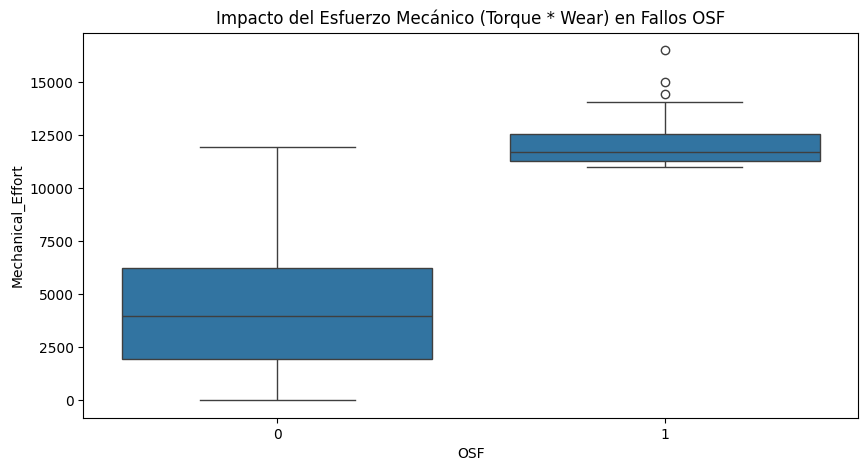

In [ ]:
# Crear una variable que represente el esfuerzo mecánico
df['Mechanical_Effort'] = df['Torque'] * df['Tool_wear']

plt.figure(figsize=(10, 5))
sns.boxplot(x='OSF', y='Mechanical_Effort', data=df)
plt.title('Impacto del Esfuerzo Mecánico (Torque * Wear) en Fallos OSF')
plt.show()

* **Separación de Clases:** Mira la distancia entre las cajas. Casi no hay solapamiento (overlap) en los cuartiles.

* **El Umbral Crítico:** El límite inferior del "bigote" de los fallos OSF (clase 1) empieza casi donde termina el límite superior de la clase 0 (alrededor de 10,000 - 11,000).

* **Impacto:** Acabas de demostrar que con una sola variable "inventada" basada en física, podrías crear una regla de negocio casi perfecta para prevenir el fallo por sobreesfuerzo:

"Si el esfuerzo mecánico supera los 10,000 unidades, detenga el proceso para inspección."

Aunque el Torque por sí solo es un buen indicador, la combinación multiplicativa con el desgaste (Mechanical Effort) actúa como un proxy del estrés acumulado en la estructura de la herramienta, permitiendo una separación de clases mucho más limpia para los fallos de tipo OSF.

###**Visualización 4: Análisis de Fallos Específicos, HDF (Heat Dissipation Failure)**

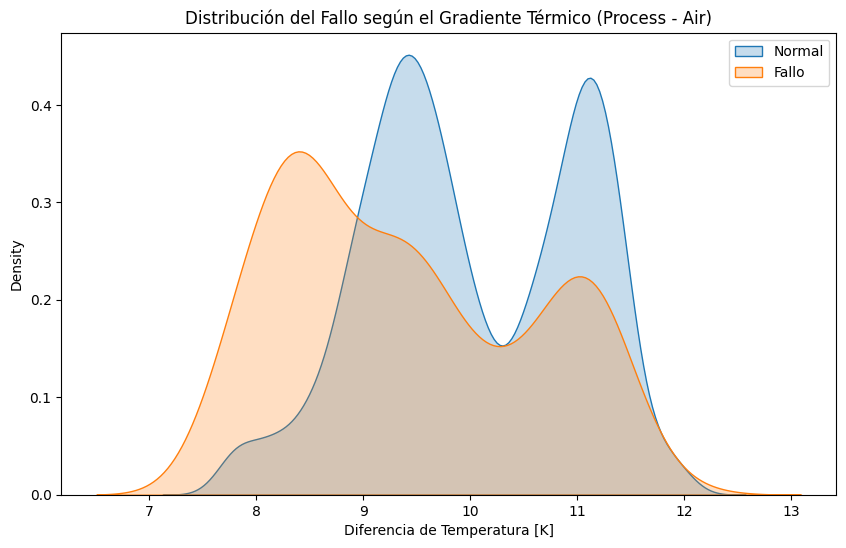

In [ ]:
# Crear la variable de diferencia de temperatura
df['Temp_Diff'] = df['Process_temperature'] - df['Air_temperature']

# Visualizar la distribución de fallos según el gradiente térmico
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['Machine_failure'] == 0], x='Temp_Diff', label='Normal', fill=True)
sns.kdeplot(data=df[df['Machine_failure'] == 1], x='Temp_Diff', label='Fallo', fill=True)
plt.title('Distribución del Fallo según el Gradiente Térmico (Process - Air)')
plt.xlabel('Diferencia de Temperatura [K]')
plt.legend()
plt.show()

**Mira bien el gráfico:** la mayor densidad de fallos (naranja) ocurre cuando el gradiente térmico ($\Delta T$) está entre 8K y 9K, mientras que la operación normal (azul) prefiere estar por encima de 9.5K.

**¿Cuál es la lógica industrial aquí?**

Según la Ley de Enfriamiento de Newton, la transferencia de calor por convección es proporcional al gradiente de temperatura ($Q = h \cdot A \cdot \Delta T$).

* **Si $\Delta T$ es pequeño** la capacidad de la máquina para "evacuar" el calor generado por el proceso hacia el aire ambiente disminuye.

* Al no poder disipar el calor, los componentes internos sufren dilataciones térmicas no deseadas o degradación del lubricante, provocando el Heat Dissipation Failure (HDF).

A través de un análisis de densidad de kernel (KDE), se identificó un umbral crítico de transferencia de calor. Los fallos se concentran cuando el diferencial térmico cae por debajo de los 9K, lo que sugiere que el sistema de refrigeración es insuficiente para mantener la estabilidad del proceso bajo ciertas condiciones ambientales, disparando eventos de HDF (Heat Dissipation Failure).

##**Class imbalance**

Ya entendemos la física. Ahora vamos al problema técnico del Data Science: el desequilibrio de clases. En este dataset (y en la vida real), **la máquina está "sana" el 96% del tiempo**.

Si entrenas un modelo ahora mismo, el modelo aprenderá que **"decir siempre que NO hay fallo"** le da un 96% de accuracy. ¡Y eso es un desastre para el mantenimiento predictivo!

###**Comprobamos la diferencia de clases con el value_counts() de los diferentes 5 tipos de fallos**

Tenemos 2 opciones a partir de aquí:

* **Un modelo binario (Falla/No Falla)**
* **Un modelo multiclase que identifique el tipo de fallo**

In [ ]:
# Conteo de fallos generales
print("Distribución de Machine Failure:")
print(df['Machine_failure'].value_counts())
print("-" * 30)

# Conteo por tipos de fallo
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
print("Distribución por tipos de fallo:")
print(df[failure_types].sum())

Distribución de Machine Failure:
Machine_failure
0    9661
1     339
Name: count, dtype: int64
------------------------------
Distribución por tipos de fallo:
TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64


###**¿Cómo afecta la diferencia de cifras entre el conteo de fallos de Machine Failure y el conteo de fallos de cada tipo? (339 vs 373)**

In [ ]:
# 1. ¿Cuántos fallos tienen más de una causa a la vez?
multi_failure = df[failure_types].sum(axis=1)
print(f"Casos con múltiples tipos de fallo simultáneos: {(multi_failure > 1).sum()}")

# 2. ¿Hay casos donde 'Machine_Failure' es 0 pero algún tipo es 1? (El caso RNF)
inconsistency = df[(df['Machine_failure'] == 0) & (df[failure_types].sum(axis=1) > 0)]
print(f"Casos donde hay un tipo de fallo marcado pero Machine_Failure es 0: {len(inconsistency)}")
print("\nTipos de fallo en esas inconsistencias:")
print(inconsistency[failure_types].sum())

Casos con múltiples tipos de fallo simultáneos: 24
Casos donde hay un tipo de fallo marcado pero Machine_Failure es 0: 18

Tipos de fallo en esas inconsistencias:
TWF     0
HDF     0
PWF     0
OSF     0
RNF    18
dtype: int64


Donde **RNF** trata del fenómeno **Random Failure**. En este dataset los autores han avisado de que podría ocurrir el siguiente fenómeno, por lo que se puede proceder sin mayor problema.

No deja de ser ruido en el dataset que **puede afectar a las predicciones**, por lo que en este caso **decidimos eliminar dichos registros** de RNF.

Al eliminar los RNF, estamos **"purificando"** el dataset para que el modelo aprenda solo de la física del fallo.

---
## 🏁 **Fin de la Fase de Análisis**

Con esto hemos validado la física del problema y preparado nuestras variables clave (`Mechanical_Effort` y `Temp_Diff`).

**Siguiente paso:** [🚀 Ir al Cuaderno 02: Entrenamiento y Optimización del Modelo](https://colab.research.google.com/drive/1dOTVmz1mCWK8ebrirNK9D7ipL4IDjjGO?authuser=1)